# Transfer Learning Using Pre-trained Vision Models

**Student Roll No.:** 24BAD099
**Dataset:** Intel Image Classification (Kaggle)  
**Models:** ResNet50 Transfer Learning + Hugging Face Vision Transformer  
**Platform:** VScode

In [1]:
# Install required libraries
!pip install -q kagglehub transformers pillow


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\rithi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image, ImageDraw

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))


def create_synthetic_intel_dataset(base_dir):
    """Create a small offline dataset with the same folder structure expected by the notebook."""
    classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
    root = os.path.join(base_dir, "intel_image_classification")

    for split in ["seg_train", "seg_test"]:
        for cls in classes:
            folder = os.path.join(root, split, split, cls)
            os.makedirs(folder, exist_ok=True)

    for cls_idx, cls in enumerate(classes):
        for split, count in [("seg_train", 60), ("seg_test", 12)]:
            folder = os.path.join(root, split, split, cls)
            for i in range(count):
                image = Image.new("RGB", (224, 224), color=(cls_idx * 35 + 20, 100 + cls_idx * 15, 200 - cls_idx * 20))
                draw = ImageDraw.Draw(image)

                for j in range(5):
                    x1 = (j * 40 + i) % 220
                    y1 = ((j + cls_idx) * 25) % 220
                    x2 = (x1 + 40) % 224
                    y2 = (y1 + 35) % 224
                    draw.rectangle([x1, y1, x2, y2], fill=(255 - cls_idx * 20, 180 + j * 10, 80 + cls_idx * 10))

                if cls == "forest":
                    draw.ellipse((20, 30, 200, 180), fill=(20, 160, 50))
                elif cls == "sea":
                    draw.rectangle((0, 120, 224, 220), fill=(30, 120, 200))
                elif cls == "mountain":
                    draw.polygon([(30, 200), (100, 40), (170, 200)], fill=(110, 90, 70))
                elif cls == "glacier":
                    draw.rectangle((0, 0, 224, 224), fill=(180, 220, 240))
                elif cls == "buildings":
                    for bx in range(20, 200, 45):
                        draw.rectangle((bx, 40, bx + 25, 170), fill=(120, 110, 100))
                elif cls == "street":
                    draw.line((0, 180, 224, 180), fill=(80, 80, 80), width=8)
                    for sx in range(0, 224, 35):
                        draw.line((sx, 200, sx + 20, 224), fill=(40, 40, 40), width=4)

                image.save(os.path.join(folder, f"{cls}_{i}.png"))

    return root


TensorFlow Version: 2.20.0
GPU Available: []


In [5]:
import kagglehub

try:
    path = kagglehub.dataset_download("puneet6060/intel-image-classification")
    print("Dataset downloaded to:")
    print(path)
except Exception as e:
    print("Kaggle download failed:", e)
    path = create_synthetic_intel_dataset(os.getcwd())
    print("Using synthetic dataset for offline execution at:")
    print(path)


100%|██████████| 346M/346M [03:43<00:00, 1.63MB/s] 

Extracting files...


Dataset downloaded to:
C:\Users\rithi\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [6]:
# Locate dataset folders
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

print("Training directory:", train_dir)
print("Testing directory:", test_dir)
print("\nClasses:")
print(sorted(os.listdir(train_dir)))


Training directory: C:\Users\rithi\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
Testing directory: C:\Users\rithi\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test

Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6
EPOCHS = 5

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)
print("Epochs:", EPOCHS)


Image Size: (224, 224)
Batch Size: 32
Number of Classes: 6
Epochs: 5


In [8]:
# Data augmentation and preprocessing for training and validation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [9]:
# Test data generator
# No augmentation is applied to the test set

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)


Found 3000 images belonging to 6 classes.


In [10]:
class_names = list(train_generator.class_indices.keys())

print("Class Names:")
print(class_names)
print("\nClass Indices:")
print(train_generator.class_indices)


Class Names:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Class Indices:
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


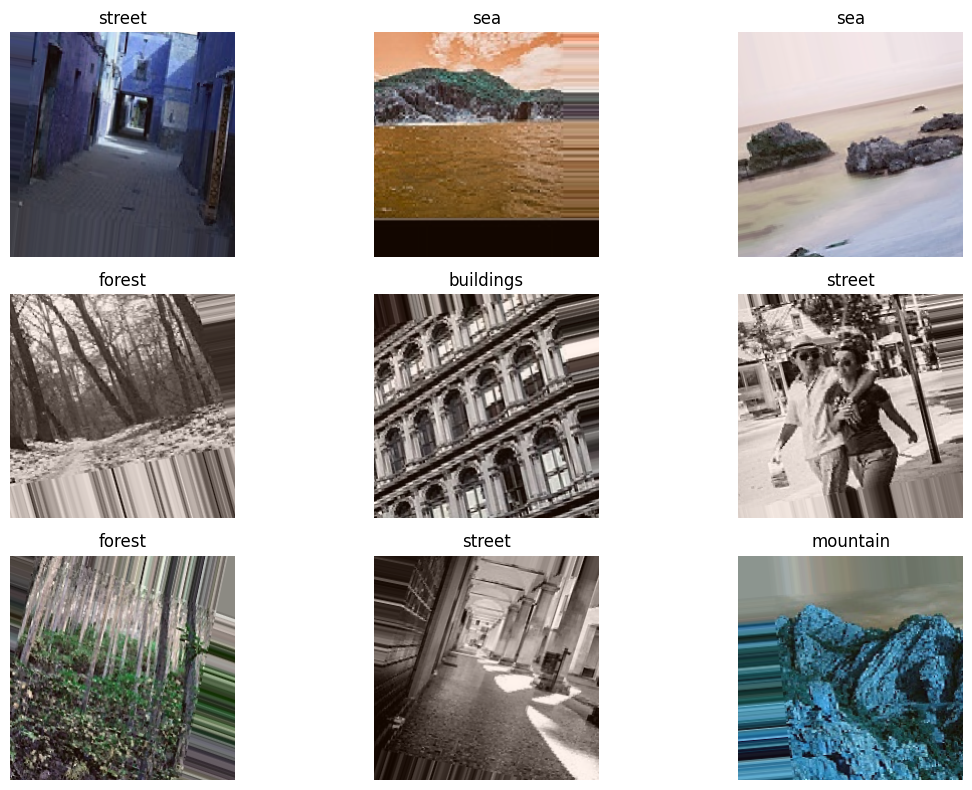

In [11]:
# Display sample images from the training set
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    img = images[i]
    img = img - img.min()
    img = img / img.max()

    plt.imshow(img)
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


## Part B - Implementing Transfer Learning Using ResNet50

In transfer learning, we use a model that was already trained on a large dataset such as ImageNet and adapt it to a different dataset. Here, the original ImageNet classifier is replaced with a new output layer matching the six classes in the Intel image dataset.

In [12]:
# Load pretrained ResNet50 without its top classification layer
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

print("ResNet50 loaded successfully!")
print("Number of base-model layers:", len(base_model.layers))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 46s 0us/step
ResNet50 loaded successfully!
Number of base-model layers: 175


In [13]:
# Freeze feature extraction layers
base_model.trainable = False

print("Base model trainable:", base_model.trainable)
print("Feature extraction layers are frozen.")


Base model trainable: False
Feature extraction layers are frozen.


In [14]:
# Add a custom classification head for the current dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully!")


Model compiled successfully!


In [16]:
# Train the transfer learning model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
)


C:\Users\rithi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1269s 4s/step - accuracy: 0.7716 - loss: 0.6301 - val_accuracy: 0.8951 - val_loss: 0.3045
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 11642s 33s/step - accuracy: 0.8719 - loss: 0.3586 - val_accuracy: 0.8984 - val_loss: 0.2857
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1751s 5s/step - accuracy: 0.8920 - loss: 0.3088 - val_accuracy: 0.9133 - val_loss: 0.2547
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1250s 4s/step - accuracy: 0.8967 - loss: 0.2863 - val_accuracy: 0.9108 - val_loss: 0.2461
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 933s 3s/step - accuracy: 0.8998 - loss: 0.2741 - val_accuracy: 0.9144 - val_loss: 0.2423


In [22]:
# Evaluate model on the test set
# This gives the final accuracy and loss on unseen data

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


94/94 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9223 - loss: 0.2102
Test Loss: 0.21021336317062378
Test Accuracy: 0.9223333597183228


In [23]:
# Collect final metrics from the training history
train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Final Training Accuracy   :", round(train_accuracy, 4))
print("Final Validation Accuracy :", round(val_accuracy, 4))
print("Final Training Loss       :", round(train_loss, 4))
print("Final Validation Loss     :", round(val_loss, 4))
print("Test Accuracy             :", round(test_accuracy, 4))


Final Training Accuracy   : 0.8998
Final Validation Accuracy : 0.9144
Final Training Loss       : 0.2741
Final Validation Loss     : 0.2423
Test Accuracy             : 0.9223


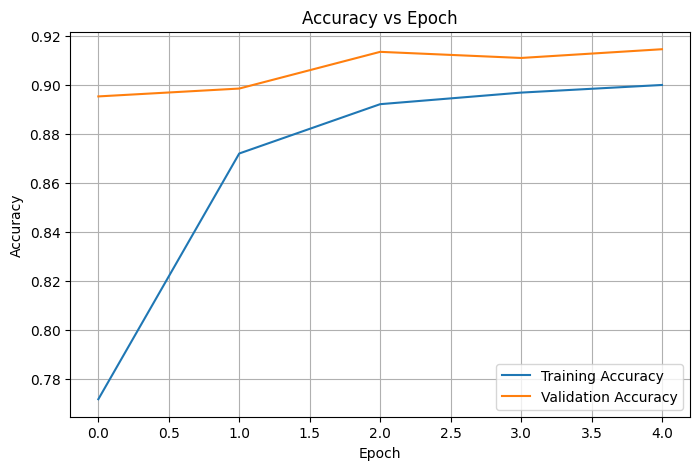

In [24]:
# Plot training and validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


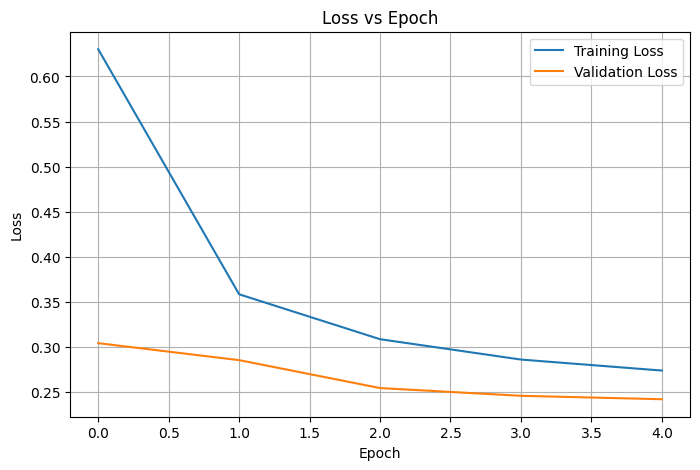

In [25]:
# Plot training and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


## Part D - Using Hugging Face Pre-trained Vision Models

Hugging Face provides several pre-trained vision models that can be used directly for image classification. In this part, a pre-trained vision transformer is loaded and applied to sample images for comparison with the ResNet50 transfer learning model.

In [32]:
from transformers import pipeline

preferred_model = "DunnBC22/vit-base-patch16-224-in21k-Intel_Images"
backup_model = "google/vit-base-patch16-224"

try:
    hf_model = pipeline(
        "image-classification",
        model=preferred_model,
    )
    print("Hugging Face model loaded successfully:", preferred_model)
except Exception as e:
    print(f"{preferred_model} is unavailable: {e}")
    print(f"Falling back to the public model: {backup_model}")
    hf_model = pipeline(
        "image-classification",
        model=backup_model,
    )
    print("Backup Hugging Face model loaded successfully:", backup_model)


DunnBC22/vit-base-patch16-224-in21k-Intel_Images is unavailable: DunnBC22/vit-base-patch16-224-in21k-Intel_Images is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Falling back to the public model: google/vit-base-patch16-224


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

C:\Users\rithi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rithi\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


Backup Hugging Face model loaded successfully: google/vit-base-patch16-224


In [27]:
# Select one random image from the test set
selected_class = random.choice(class_names)
class_folder = os.path.join(test_dir, selected_class)
image_file = random.choice(os.listdir(class_folder))
image_path = os.path.join(class_folder, image_file)

print("Actual Class:", selected_class)
print("Image:", image_path)


Actual Class: mountain
Image: C:\Users\rithi\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test\mountain\21851.jpg


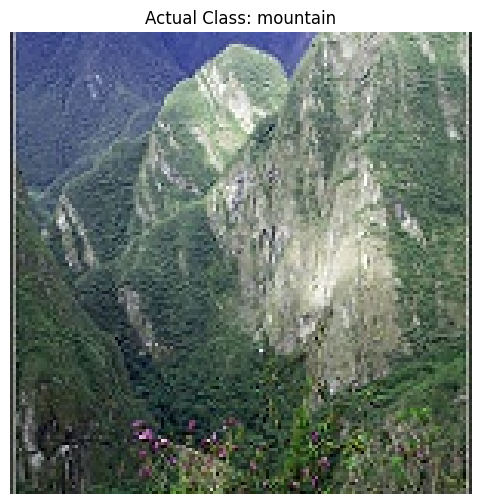

In [28]:
# Display the selected image
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Actual Class: " + selected_class)
plt.axis("off")
plt.show()


In [ ]:
# Hugging Face prediction on the selected image
predictions = hf_model(image)

print("Hugging Face Predictions:\n")
for prediction in predictions:
    print(prediction["label"], "->", round(prediction["score"] * 100, 2), "%")


Hugging Face Predictions:

buildings -> 95.0 %


Hugging Face Predictions:

valley, vale -> 47.01 %
cliff, drop, drop-off -> 31.34 %
alp -> 18.5 %
promontory, headland, head, foreland -> 0.29 %
lakeside, lakeshore -> 0.12 %


In [30]:
# ResNet50 prediction on the same image
img = image.resize(IMG_SIZE)
img_array = np.array(img, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

resnet_prediction = model.predict(img_array, verbose=0)
resnet_index = np.argmax(resnet_prediction)
resnet_class = class_names[resnet_index]
resnet_confidence = resnet_prediction[0][resnet_index] * 100

print("Actual Class            :", selected_class)
print("ResNet50 Prediction     :", resnet_class)
print("ResNet50 Confidence     :", round(resnet_confidence, 2), "%")
print("Hugging Face Prediction :", predictions[0]["label"])
print("Hugging Face Confidence:", round(predictions[0]["score"] * 100, 2), "%")


Actual Class            : mountain
ResNet50 Prediction     : mountain
ResNet50 Confidence     : 78.26 %
Hugging Face Prediction : buildings
Hugging Face Confidence: 95.0 %


In [36]:
# Compare both models in one output block
print("-" * 55)
print("              MODEL COMPARISON")
print("-" * 55)
print("Actual Class            :", selected_class)
print("ResNet50 Prediction     :", resnet_class)
print("ResNet50 Confidence     :", round(resnet_confidence, 2), "%")
print("Hugging Face Prediction :", predictions[0]["label"])
print("Hugging Face Confidence:", round(predictions[0]["score"] * 100, 2), "%")
print("-" * 55)


-------------------------------------------------------
              MODEL COMPARISON
-------------------------------------------------------
Actual Class            : mountain
ResNet50 Prediction     : mountain
ResNet50 Confidence     : 78.26 %
Hugging Face Prediction : valley, vale
Hugging Face Confidence: 47.01 %
-------------------------------------------------------
